In [52]:
import pandas as pd
import os
import numpy as np
from scipy.stats import kstest, ks_2samp
from scipy.stats import wilcoxon
from scipy.stats import ttest_rel
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
# Cargamos los csv
path = "saved_files/"
dfs = {}
for archivo in os.listdir(path):
    if archivo.startswith("df_tiffs_") and archivo.endswith(".csv"):
        nombre_sin_extension = os.path.splitext(archivo)[0]  # sin .csv
        ruta_completa = os.path.join(path, archivo)
        dfs[nombre_sin_extension] = pd.read_csv(ruta_completa)

### Comparación de los grupos 1x1, 3x3, 5x5 y 9x9

Utilizamos tests para comparar muestras emparejadas y así ver si las reflectancias siguen la misma distribución.

Primero hay que comprobar que las muestras siguen una distribución normal - One Sample Kolmnogorov Smirnov Test

Las reflectancias no siguen una distribución normal:


In [43]:
reference = 'norm'  # Reference distribution (normal distribution)
bands = ['Band_1', 'Band_2', 'Band_3','Band_4', 'Band_5', 'Band_6', 'Band_7', 'Band_8', 'Band_9', 'Band_10','Band_11', 'Band_12', 'Band_13', 'Band_14']
groups = ["1x1", "3x3", "5x5", "9x9"]
for group in groups:
    for band in bands:
        print(f"Evaluating {band} in {group}")
        # One Sample K-S Test
        stat, p_value = kstest(dfs[f"df_tiffs_c2x-complex-nets_{group}"][band], reference)
        #print(f'K-S Test Statistic (One-Sample): {stat}')
        #print(f'P-value: {p_value}')
        alpha = 0.1
        if p_value > alpha:
            print("Fail to reject the null hypothesis: The sample comes from the specified distribution.")
        else:
            print("Reject the null hypothesis: The sample does not come from the specified distribution.")
        print()

Evaluating Band_1 in 1x1
Reject the null hypothesis: The sample does not come from the specified distribution.

Evaluating Band_2 in 1x1
Reject the null hypothesis: The sample does not come from the specified distribution.

Evaluating Band_3 in 1x1
Reject the null hypothesis: The sample does not come from the specified distribution.

Evaluating Band_4 in 1x1
Reject the null hypothesis: The sample does not come from the specified distribution.

Evaluating Band_5 in 1x1
Reject the null hypothesis: The sample does not come from the specified distribution.

Evaluating Band_6 in 1x1
Reject the null hypothesis: The sample does not come from the specified distribution.

Evaluating Band_7 in 1x1
Reject the null hypothesis: The sample does not come from the specified distribution.

Evaluating Band_8 in 1x1
Reject the null hypothesis: The sample does not come from the specified distribution.

Evaluating Band_9 in 1x1
Reject the null hypothesis: The sample does not come from the specified distrib

Para comparar las muestras utilizamos el test de Wilcoxon Signed-Rank Test que es la alternativa no parámetrica al paired t-test. Encontramos que de acuerdo a esto, la mediana de las diferencias sí que es cero y el efffect size es pequeño (a partir de 0.2 sería preocupante). 

El problema es que sabemos que no es lo mismo utilizar unas reflectancias que otras. Para ver esto añadimos un histograma en el que se vea la diferencia porcentual. Al observar esto vemos que aunque la mediana esté centrada en cero, sí hay diferencias importantes entre las distintas agrupaciones, y la que más se parece es la de 3x3 con 5x5.

Evaluating Band_1 for groups 1x1 and 3x3
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.130



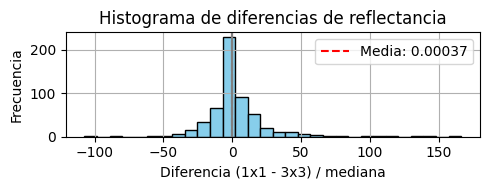

Evaluating Band_2 for groups 1x1 and 3x3
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.117



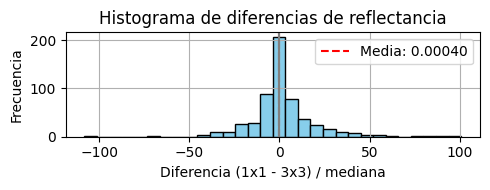

Evaluating Band_3 for groups 1x1 and 3x3
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.103



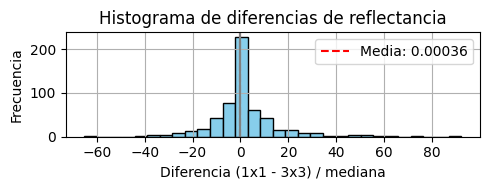

Evaluating Band_4 for groups 1x1 and 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.148



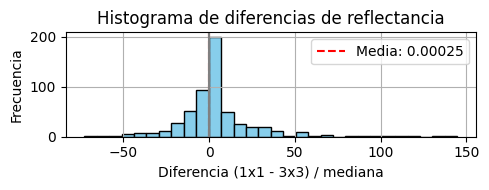

Evaluating Band_5 for groups 1x1 and 3x3
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.096



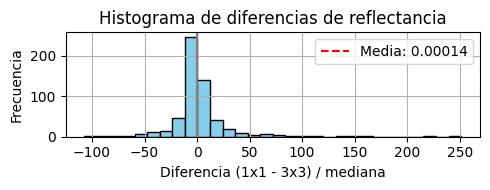

Evaluating Band_6 for groups 1x1 and 3x3
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.108



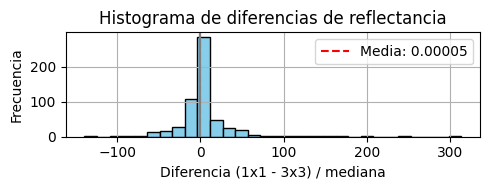

Evaluating Band_7 for groups 1x1 and 3x3
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.111



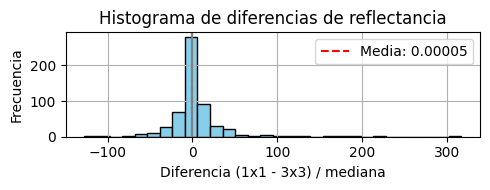

Evaluating Band_8 for groups 1x1 and 3x3
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.115



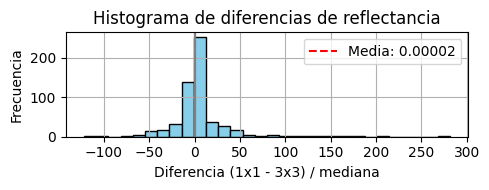

Evaluating Band_9 for groups 1x1 and 3x3
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.127



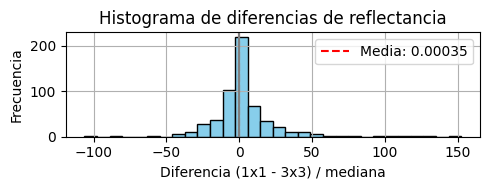

Evaluating Band_10 for groups 1x1 and 3x3
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.117



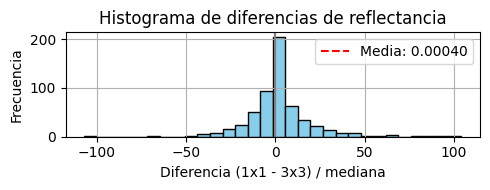

Evaluating Band_11 for groups 1x1 and 3x3
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.105



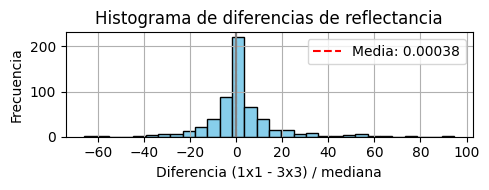

Evaluating Band_12 for groups 1x1 and 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.141



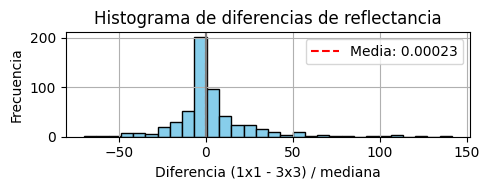

Evaluating Band_13 for groups 1x1 and 3x3
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.116



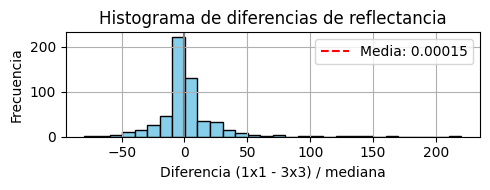

Evaluating Band_14 for groups 1x1 and 3x3
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.096



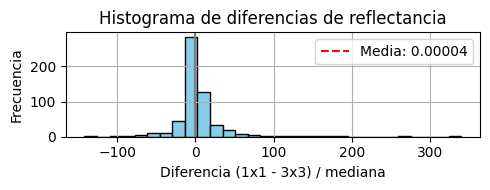

----------------------------------------------------------------
Evaluating Band_1 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.091



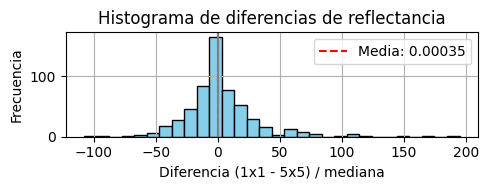

Evaluating Band_2 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.078



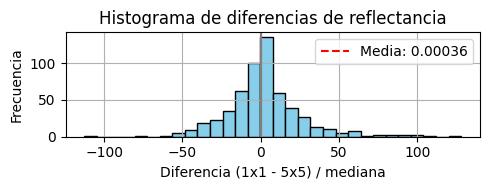

Evaluating Band_3 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.076



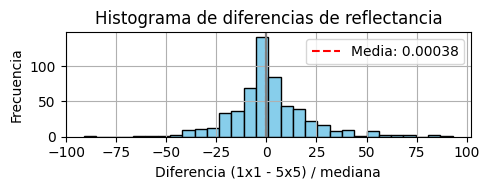

Evaluating Band_4 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.125



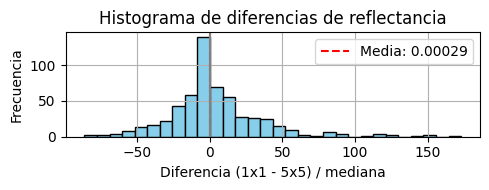

Evaluating Band_5 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.091



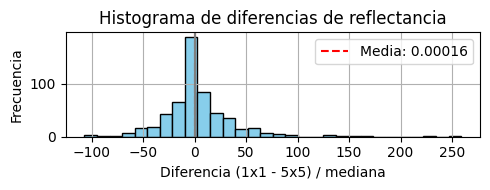

Evaluating Band_6 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.109



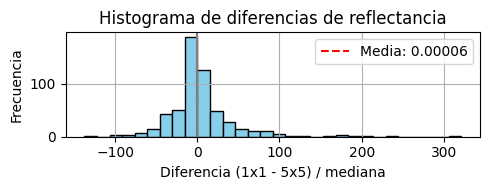

Evaluating Band_7 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.109



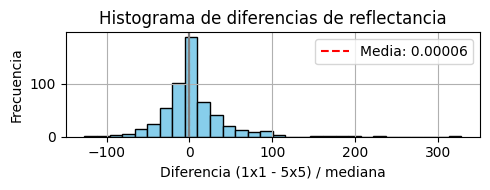

Evaluating Band_8 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.112



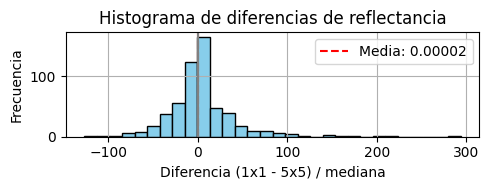

Evaluating Band_9 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.087



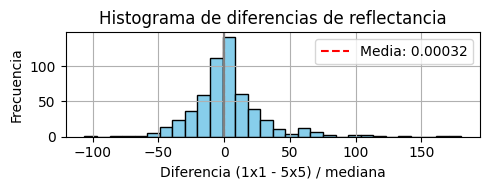

Evaluating Band_10 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.080



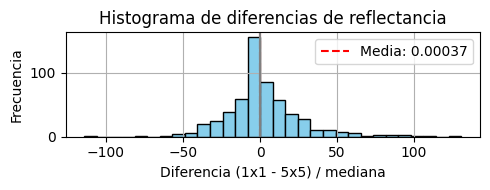

Evaluating Band_11 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.077



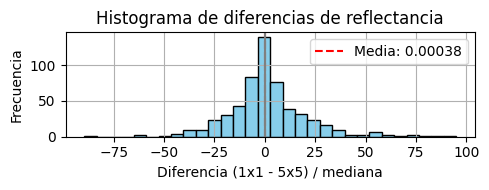

Evaluating Band_12 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.115



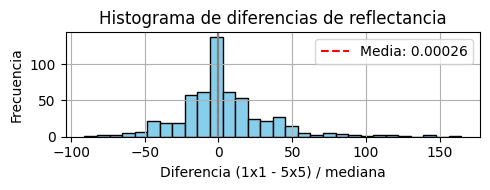

Evaluating Band_13 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.105



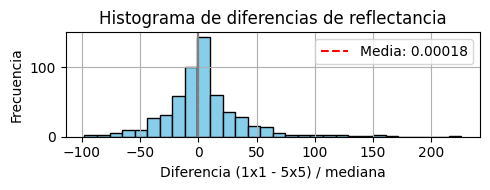

Evaluating Band_14 for groups 1x1 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.096



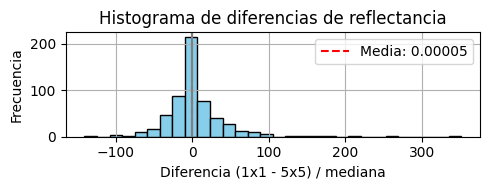

----------------------------------------------------------------
Evaluating Band_1 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.113



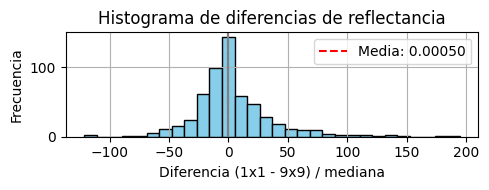

Evaluating Band_2 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.108



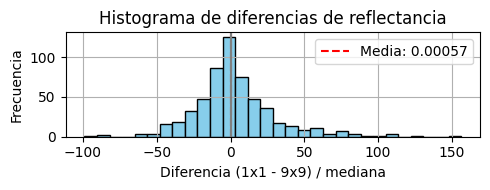

Evaluating Band_3 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.097



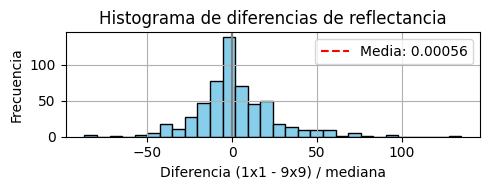

Evaluating Band_4 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.145



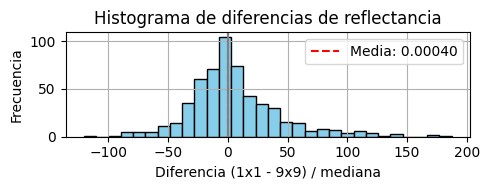

Evaluating Band_5 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.096



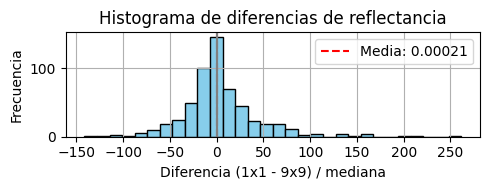

Evaluating Band_6 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.105



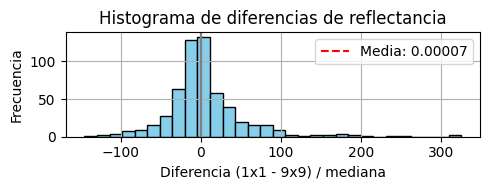

Evaluating Band_7 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.105



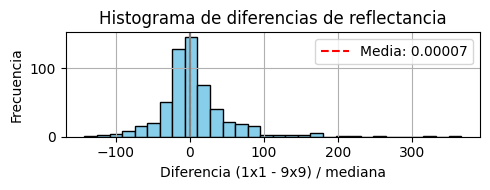

Evaluating Band_8 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.106



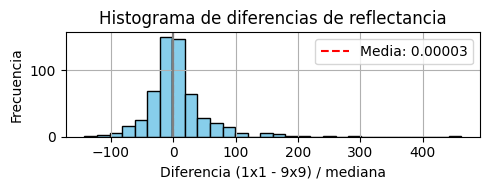

Evaluating Band_9 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.109



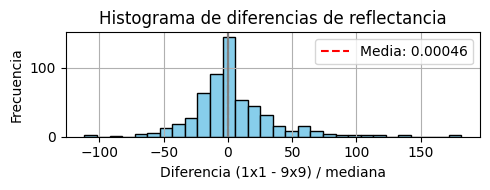

Evaluating Band_10 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.111



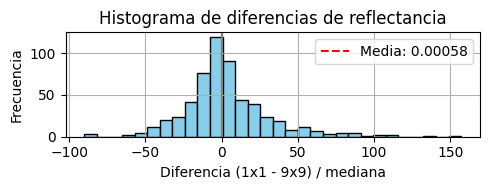

Evaluating Band_11 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.098



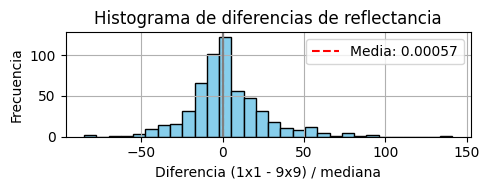

Evaluating Band_12 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.136



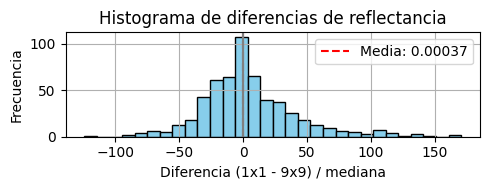

Evaluating Band_13 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.110



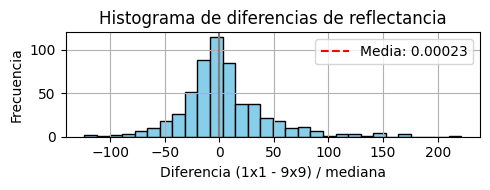

Evaluating Band_14 for groups 1x1 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.091



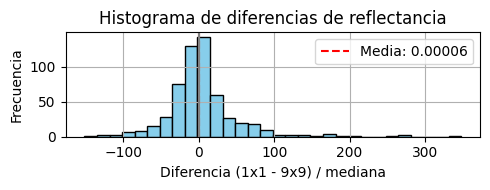

----------------------------------------------------------------
Evaluating Band_1 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: -0.016



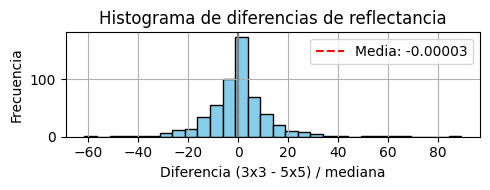

Evaluating Band_2 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: -0.021



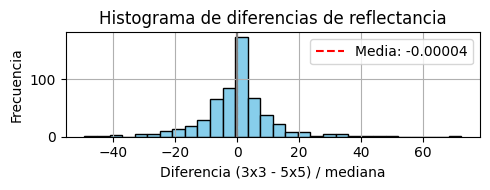

Evaluating Band_3 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.006



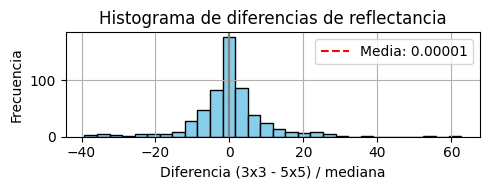

Evaluating Band_4 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.037



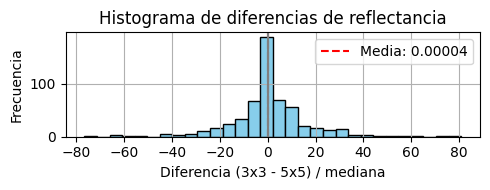

Evaluating Band_5 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.030



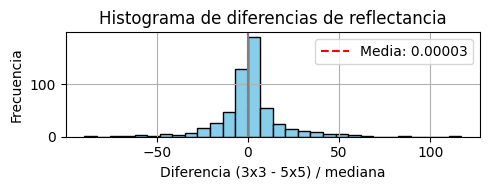

Evaluating Band_6 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.044



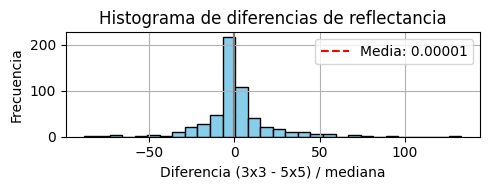

Evaluating Band_7 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.039



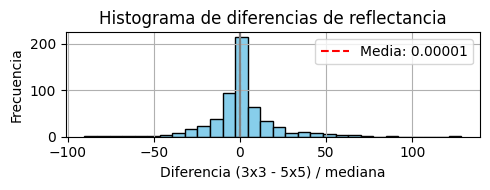

Evaluating Band_8 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.042



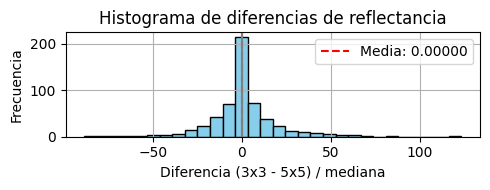

Evaluating Band_9 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: -0.018



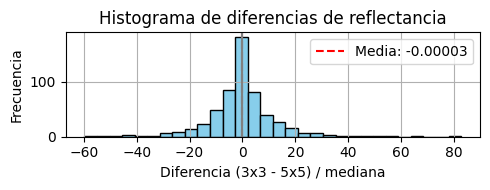

Evaluating Band_10 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: -0.016



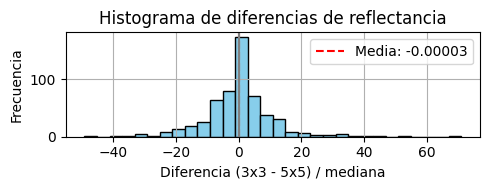

Evaluating Band_11 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.003



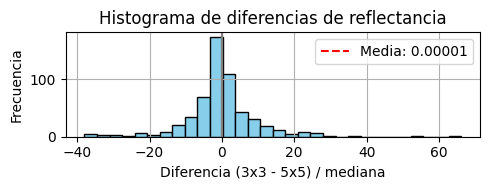

Evaluating Band_12 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.027



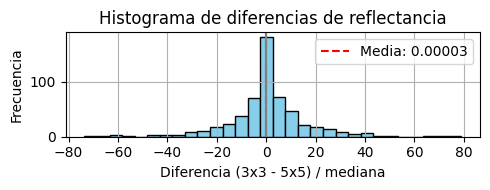

Evaluating Band_13 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.032



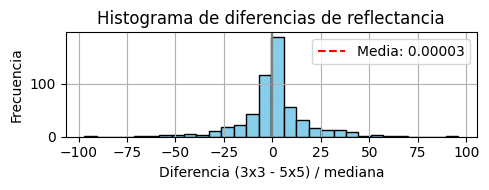

Evaluating Band_14 for groups 3x3 and 5x5
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.037



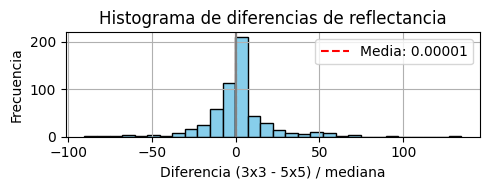

----------------------------------------------------------------
Evaluating Band_1 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.044



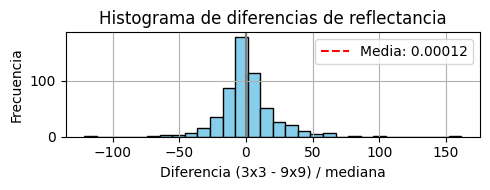

Evaluating Band_2 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.051



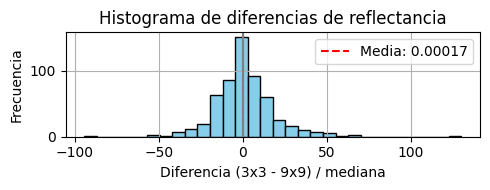

Evaluating Band_3 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.051



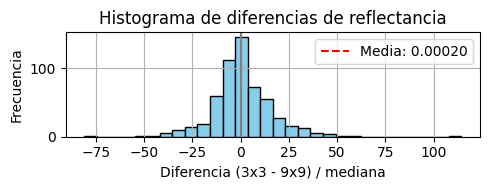

Evaluating Band_4 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.084



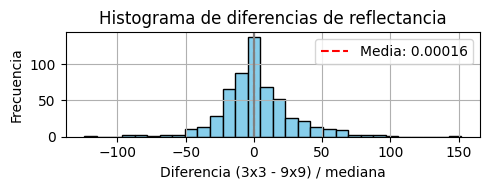

Evaluating Band_5 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.048



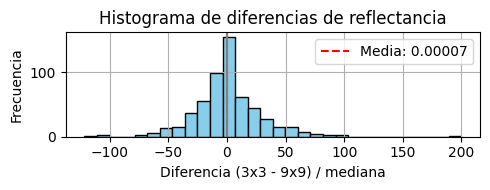

Evaluating Band_6 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.050



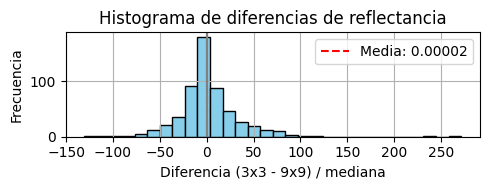

Evaluating Band_7 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.049



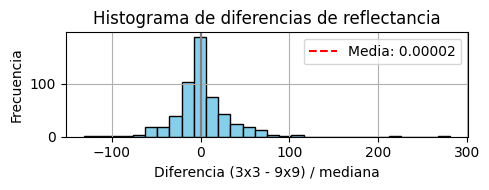

Evaluating Band_8 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.051



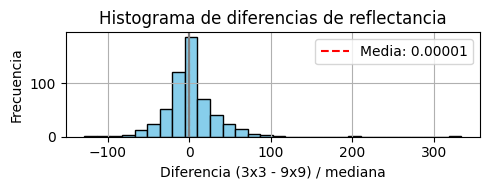

Evaluating Band_9 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.041



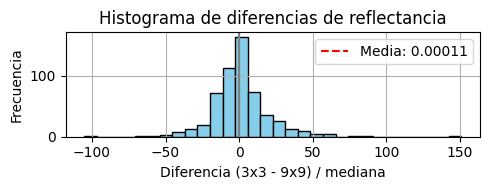

Evaluating Band_10 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.056



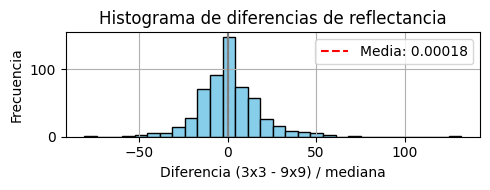

Evaluating Band_11 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.050



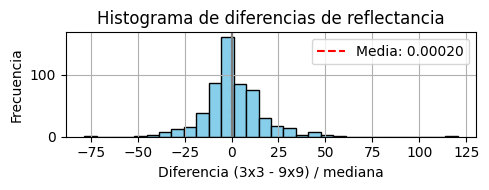

Evaluating Band_12 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.075



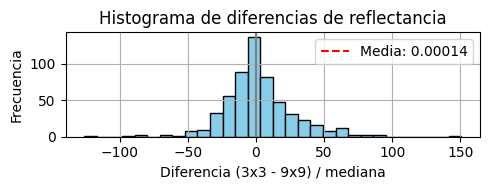

Evaluating Band_13 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.054



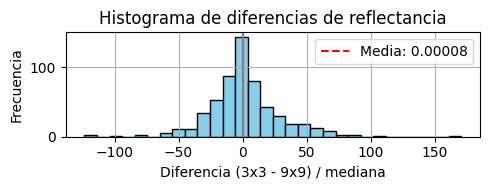

Evaluating Band_14 for groups 3x3 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.039



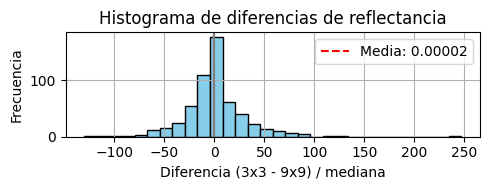

----------------------------------------------------------------
Evaluating Band_1 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.084



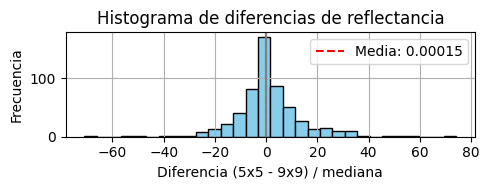

Evaluating Band_2 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.101



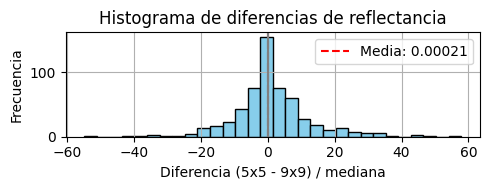

Evaluating Band_3 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.076



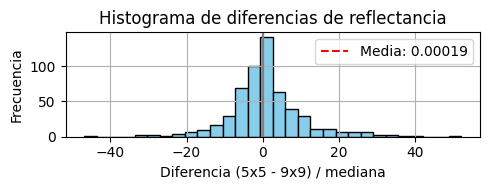

Evaluating Band_4 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.100



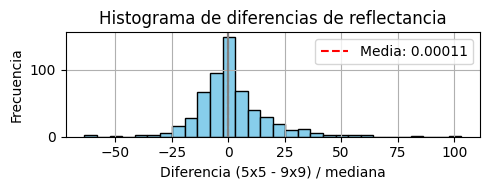

Evaluating Band_5 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.047



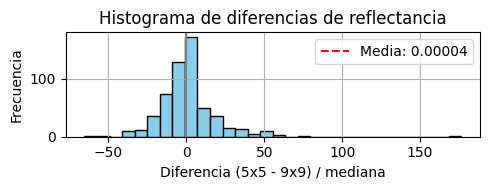

Evaluating Band_6 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.036



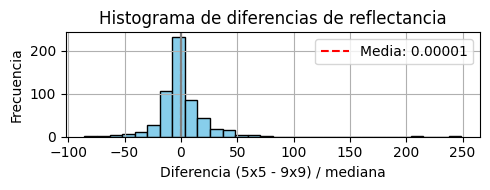

Evaluating Band_7 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.039



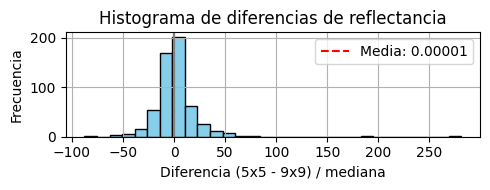

Evaluating Band_8 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.041



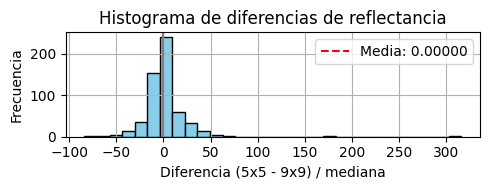

Evaluating Band_9 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.082



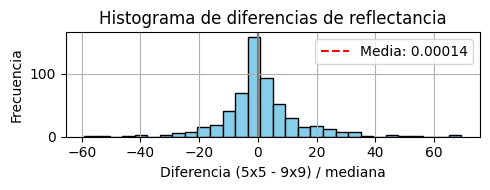

Evaluating Band_10 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.103



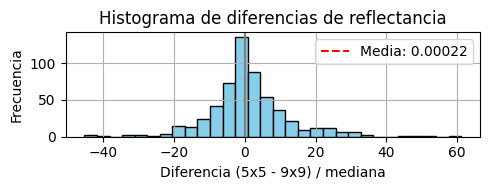

Evaluating Band_11 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.078



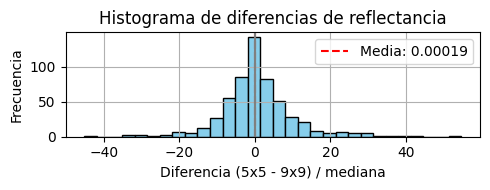

Evaluating Band_12 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.096



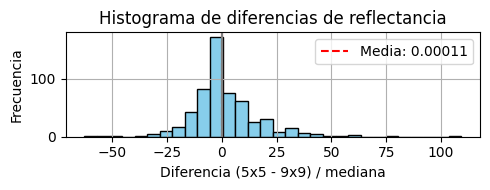

Evaluating Band_13 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.056



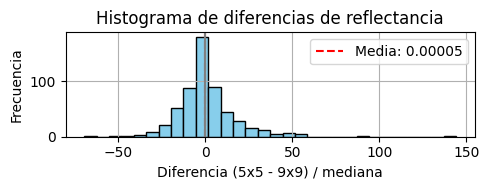

Evaluating Band_14 for groups 5x5 and 9x9
Fail to reject the null hypothesis: The median difference is zero.
Tamaño del efecto: 0.026



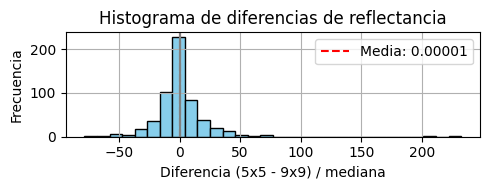

----------------------------------------------------------------


In [56]:
bands = ['Band_1', 'Band_2', 'Band_3','Band_4', 'Band_5', 'Band_6', 'Band_7', 'Band_8', 'Band_9', 'Band_10','Band_11', 'Band_12', 'Band_13', 'Band_14']
groups = ["1x1", "3x3", "5x5", "9x9"]
for pair1, pair2 in combinations(groups, 2):
    for band in bands:
        print(f"Evaluating {band} for groups {pair1} and {pair2}")
        stat, p_value = wilcoxon(dfs[f"df_tiffs_c2x-complex-nets_{pair1}"][band], dfs[f"df_tiffs_c2x-complex-nets_{pair2}"][band])
        #print(f'Wilcoxon Signed-Rank Test Statistic: {stat}')
        #print(f'P-value: {p_value}')

        alpha = 0.05
        if p_value > alpha:
            print("Fail to reject the null hypothesis: The median difference is zero.")
        else:
            print("Reject the null hypothesis: The median difference is not zero.")

        diffs = dfs[f"df_tiffs_c2x-complex-nets_{pair1}"][band] - dfs[f"df_tiffs_c2x-complex-nets_{pair2}"][band]
        effect_size = diffs.mean() / diffs.std()
        print(f"Tamaño del efecto: {effect_size:.3f}")
        print()

        plt.figure(figsize=(5,2))
        plt.hist(diffs / dfs[f"df_tiffs_c2x-complex-nets_{pair2}"][band].median()*100, bins=30, color='skyblue', edgecolor='black')
        plt.axvline(diffs.mean(), color='red', linestyle='--', label=f"Media: {diffs.mean():.5f}")
        plt.axvline(0, color='gray', linestyle='-')
        plt.title("Histograma de diferencias de reflectancia")
        plt.xlabel(f"Diferencia ({pair1} - {pair2}) / mediana")
        plt.ylabel("Frecuencia")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    print("----"*16)

Aunque no se cumpla la condición de normalidad, probamos a aplicar el test t, ya que si hay más de 30 observaciones, y la distribución de diferencias no es extremadamente asimétrica, el test t puede ser robusto. Y como hemos visto más arriba las distribuciones de diferencias sí son simétricas.

In [57]:
bands = ['Band_1', 'Band_2', 'Band_3','Band_4', 'Band_5', 'Band_6', 'Band_7', 'Band_8', 'Band_9', 'Band_10','Band_11', 'Band_12', 'Band_13', 'Band_14']
groups = ["1x1", "3x3", "5x5", "9x9"]
for pair1, pair2 in combinations(groups, 2):
    for band in bands:
        print(f"Evaluating {band} for groups {pair1} and {pair2}")
        stat, p_value = ttest_rel(dfs[f"df_tiffs_c2x-complex-nets_{pair1}"][band], dfs[f"df_tiffs_c2x-complex-nets_{pair2}"][band])
        #print(f'Test Statistic: {stat}')
        #print(f'P-value: {p_value}')

        alpha = 0.05
        if p_value > alpha:
            print("Fail to reject the null hypothesis: The mean difference is zero.")
        else:
            print("Reject the null hypothesis: The mean difference is not zero.")
        print()
    print("----"*16)

Evaluating Band_1 for groups 1x1 and 3x3
Reject the null hypothesis: The mean difference is not zero.

Evaluating Band_2 for groups 1x1 and 3x3
Reject the null hypothesis: The mean difference is not zero.

Evaluating Band_3 for groups 1x1 and 3x3
Reject the null hypothesis: The mean difference is not zero.

Evaluating Band_4 for groups 1x1 and 3x3
Reject the null hypothesis: The mean difference is not zero.

Evaluating Band_5 for groups 1x1 and 3x3
Reject the null hypothesis: The mean difference is not zero.

Evaluating Band_6 for groups 1x1 and 3x3
Reject the null hypothesis: The mean difference is not zero.

Evaluating Band_7 for groups 1x1 and 3x3
Reject the null hypothesis: The mean difference is not zero.

Evaluating Band_8 for groups 1x1 and 3x3
Reject the null hypothesis: The mean difference is not zero.

Evaluating Band_9 for groups 1x1 and 3x3
Reject the null hypothesis: The mean difference is not zero.

Evaluating Band_10 for groups 1x1 and 3x3
Reject the null hypothesis: The

Si miramos estos resultados junto con todo lo anterior, lo que podemos concluir es que:
- El grupo de 1x1 es diferente a todos los demás.
- 3x3 y 5x5 son muy similares.
- 3x3 y 9x9 se parecen aunque no tanto como 3x3 y 5x5.
- 5x5 y 9x9 también se parecen bastante, pero en menor medida que las dos parejas del item anterior.


### Comparación de C2X-Nets y C2X-Complex-Nets

Omitimos la comprobación de normalidad porque ya sabemos que no se cumple. Aplicamos directamente el test de Wilcoxon.

Evaluating Band_1 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.588



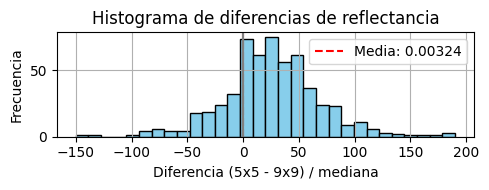

Evaluating Band_2 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.347



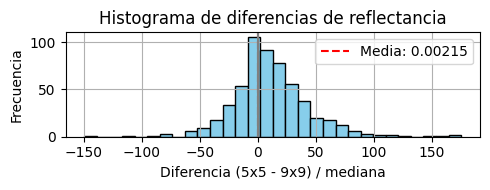

Evaluating Band_3 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.230



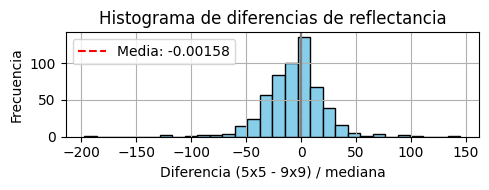

Evaluating Band_4 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.183



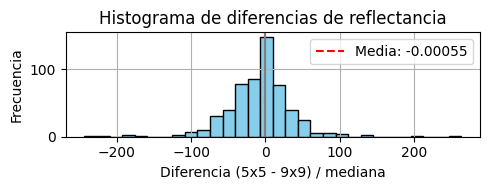

Evaluating Band_5 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.313



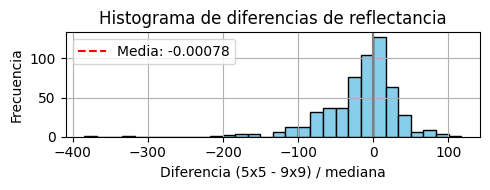

Evaluating Band_6 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.405



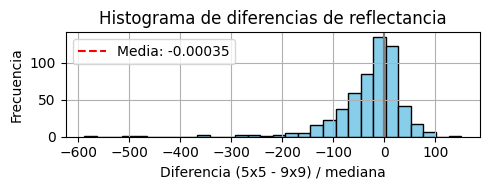

Evaluating Band_7 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.353



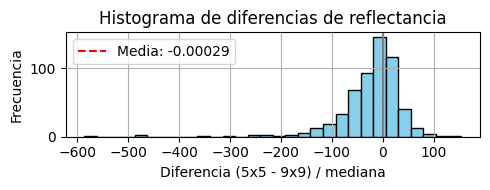

Evaluating Band_8 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.302



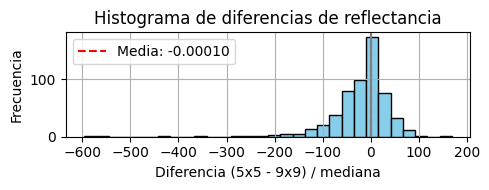

Evaluating Band_9 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.607



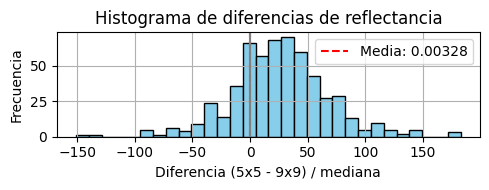

Evaluating Band_10 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.331



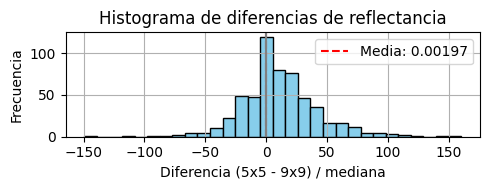

Evaluating Band_11 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.228



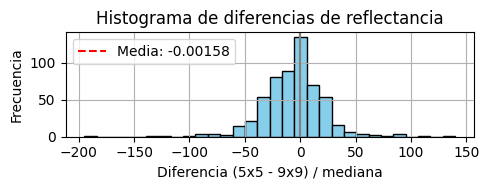

Evaluating Band_12 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.138



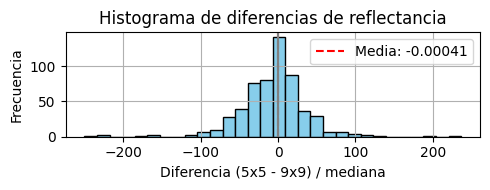

Evaluating Band_13 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.302



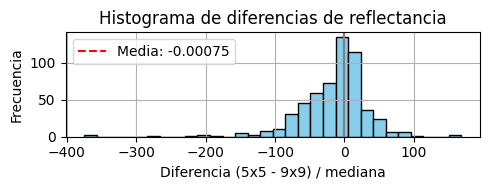

Evaluating Band_14 for group 1x1
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.425



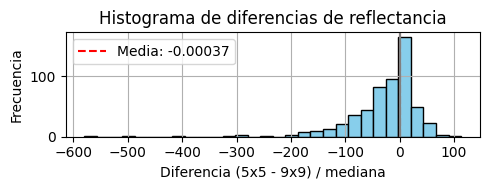

----------------------------------------------------------------
Evaluating Band_1 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.630



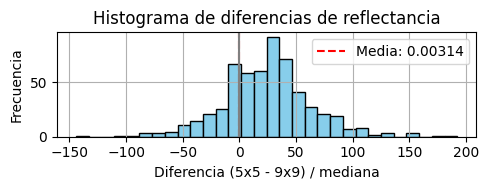

Evaluating Band_2 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.353



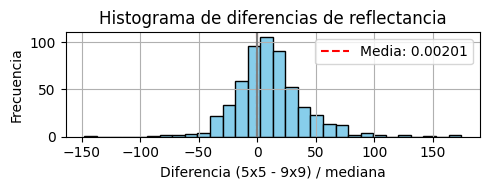

Evaluating Band_3 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.230



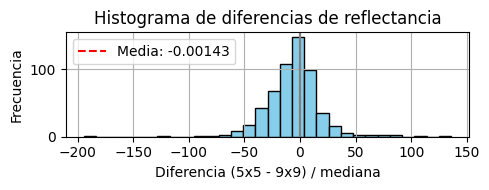

Evaluating Band_4 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.193



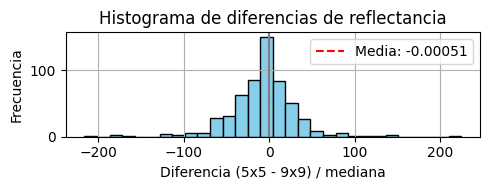

Evaluating Band_5 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.287



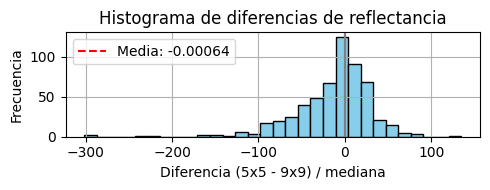

Evaluating Band_6 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.398



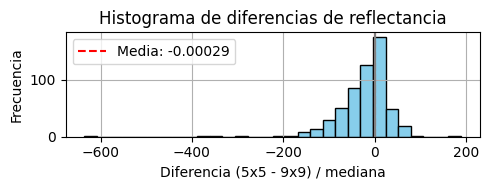

Evaluating Band_7 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.331



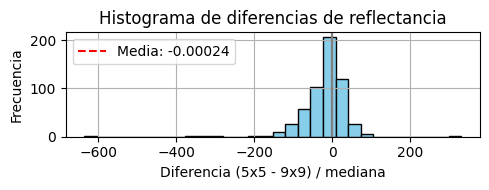

Evaluating Band_8 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.274



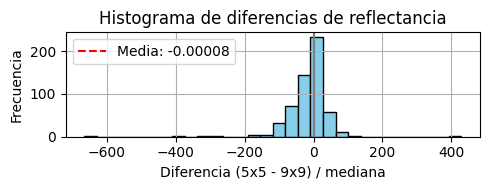

Evaluating Band_9 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.651



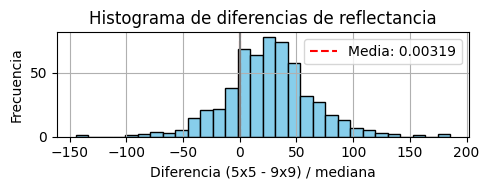

Evaluating Band_10 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.338



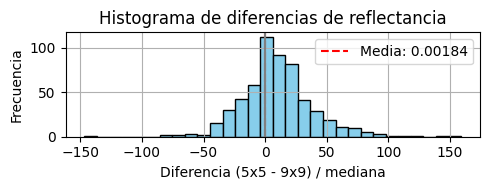

Evaluating Band_11 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.228



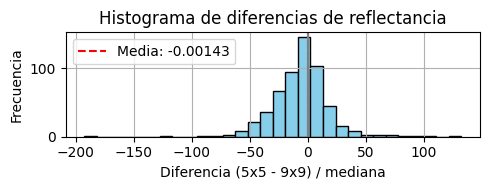

Evaluating Band_12 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.138



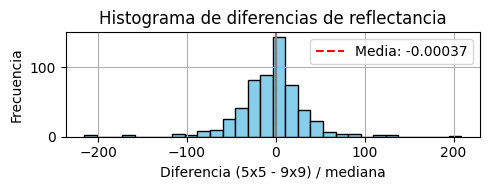

Evaluating Band_13 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.292



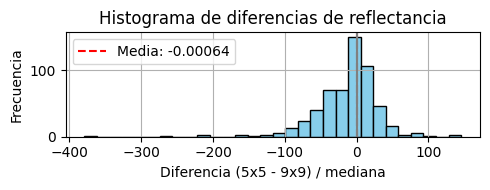

Evaluating Band_14 for group 3x3
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.419



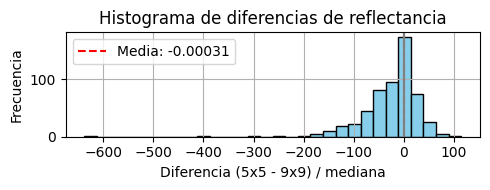

----------------------------------------------------------------
Evaluating Band_1 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.753



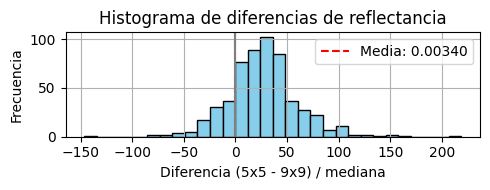

Evaluating Band_2 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.423



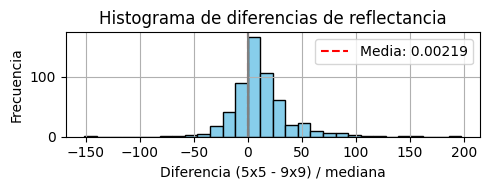

Evaluating Band_3 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.227



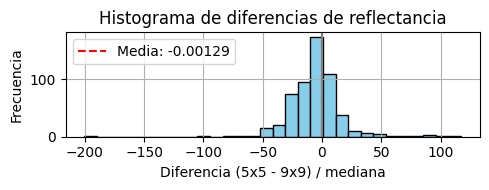

Evaluating Band_4 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.163



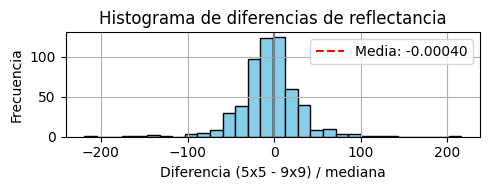

Evaluating Band_5 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.269



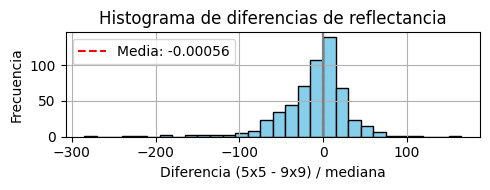

Evaluating Band_6 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.394



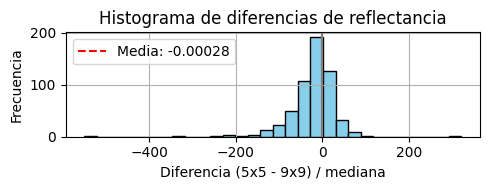

Evaluating Band_7 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.321



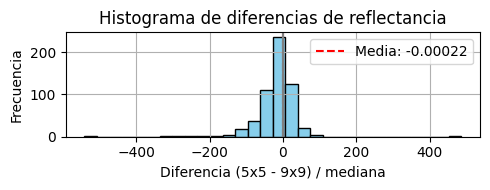

Evaluating Band_8 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.262



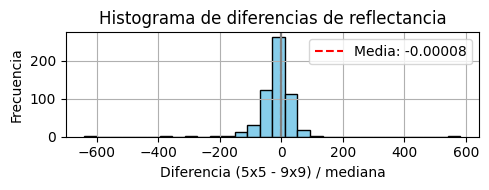

Evaluating Band_9 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.774



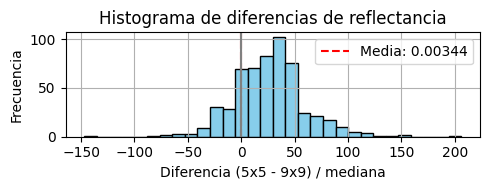

Evaluating Band_10 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.411



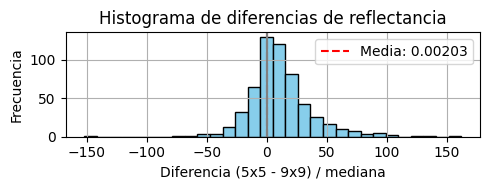

Evaluating Band_11 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.224



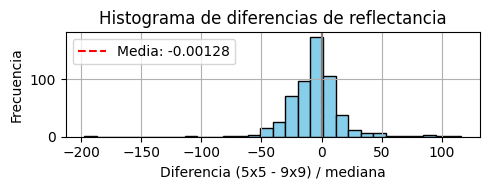

Evaluating Band_12 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.104



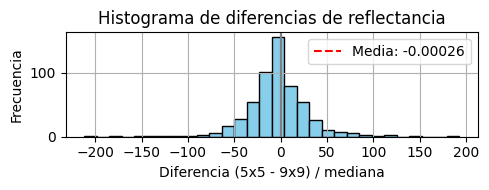

Evaluating Band_13 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.275



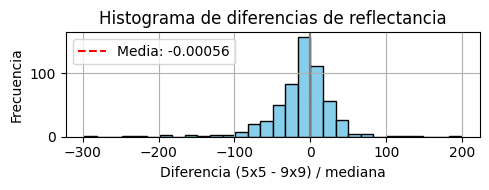

Evaluating Band_14 for group 5x5
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.421



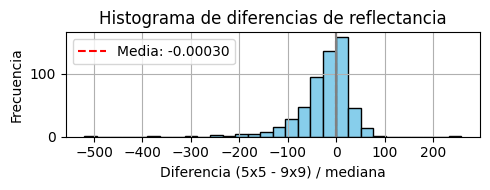

----------------------------------------------------------------
Evaluating Band_1 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.826



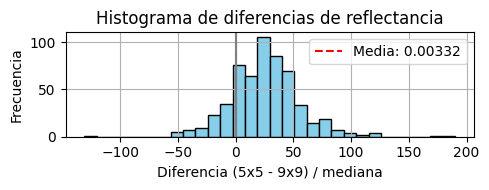

Evaluating Band_2 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.444



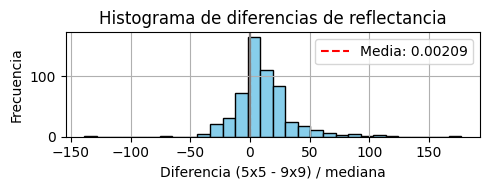

Evaluating Band_3 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.247



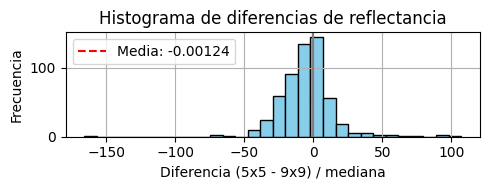

Evaluating Band_4 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.203



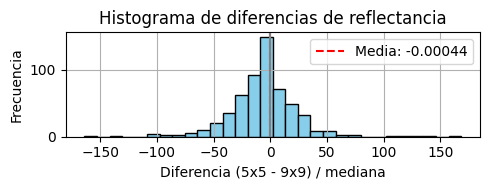

Evaluating Band_5 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.294



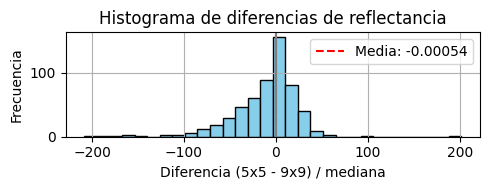

Evaluating Band_6 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.456



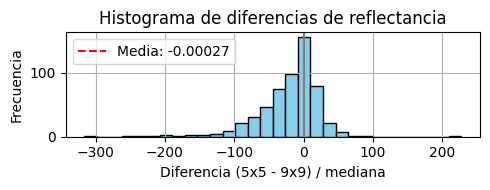

Evaluating Band_7 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.378



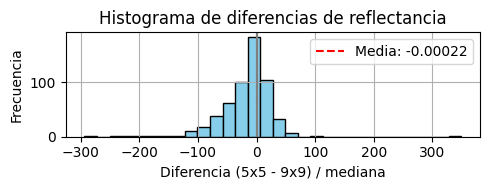

Evaluating Band_8 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.325



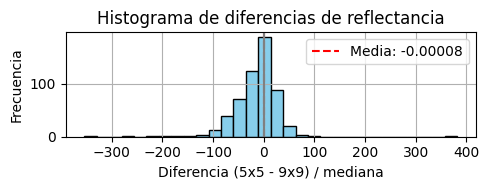

Evaluating Band_9 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.850



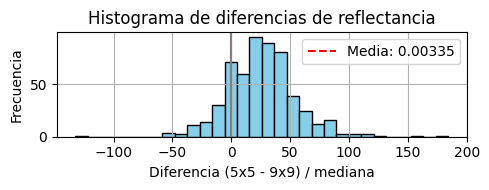

Evaluating Band_10 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: 0.433



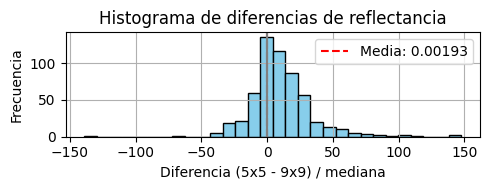

Evaluating Band_11 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.241



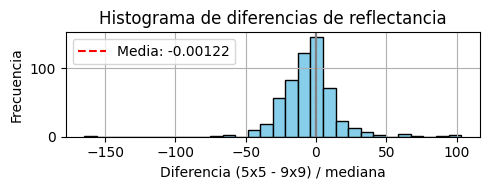

Evaluating Band_12 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.137



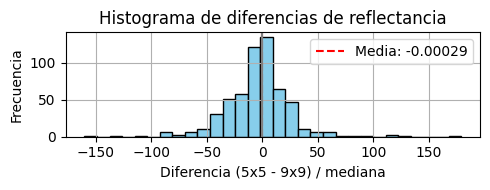

Evaluating Band_13 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.313



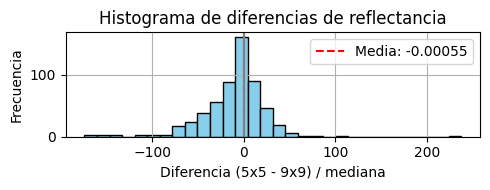

Evaluating Band_14 for group 9x9
Reject the null hypothesis: The median difference is not zero.
Tamaño del efecto: -0.476



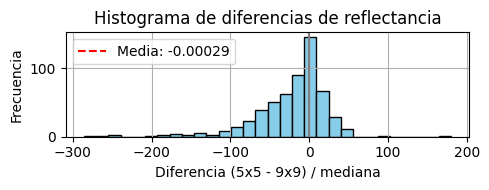

----------------------------------------------------------------


In [58]:
bands = ['Band_1', 'Band_2', 'Band_3','Band_4', 'Band_5', 'Band_6', 'Band_7', 'Band_8', 'Band_9', 'Band_10','Band_11', 'Band_12', 'Band_13', 'Band_14']
groups = ["1x1", "3x3", "5x5", "9x9"]
for group in groups:
    for band in bands:
        print(f"Evaluating {band} for group {group}")
        stat, p_value = wilcoxon(dfs[f"df_tiffs_c2x-complex-nets_{group}"][band], dfs[f"df_tiffs_c2x-nets_{group}"][band])
        #print(f'Wilcoxon Signed-Rank Test Statistic: {stat}')
        #print(f'P-value: {p_value}')

        alpha = 0.05
        if p_value > alpha:
            print("Fail to reject the null hypothesis: The median difference is zero.")
        else:
            print("Reject the null hypothesis: The median difference is not zero.")

        diffs = dfs[f"df_tiffs_c2x-complex-nets_{group}"][band] - dfs[f"df_tiffs_c2x-nets_{group}"][band]
        effect_size = diffs.mean() / diffs.std()
        print(f"Tamaño del efecto: {effect_size:.3f}")
        print()

        plt.figure(figsize=(5,2))
        plt.hist(diffs / dfs[f"df_tiffs_c2x-complex-nets_{group}"][band].median()*100, bins=30, color='skyblue', edgecolor='black')
        plt.axvline(diffs.mean(), color='red', linestyle='--', label=f"Media: {diffs.mean():.5f}")
        plt.axvline(0, color='gray', linestyle='-')
        plt.title("Histograma de diferencias de reflectancia")
        plt.xlabel(f"Diferencia ({pair1} - {pair2}) / mediana")
        plt.ylabel("Frecuencia")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    print("----"*16)

Aparentemente sí hay mucha diferencia entre las reflectancias obtenidas mediante los dos métodos.